<a href="https://colab.research.google.com/github/Tanvi-diwakar/Ml_concepts/blob/main/Binning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv('Titanic-Dataset.csv', usecols=['Age','Fare','Survived'])

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(714, 3)

In [ ]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.6153846153846154

In [ ]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6274843505477309)

In [ ]:
kbin_age = KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')
kbin_fare = KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='kmeans')

In [ ]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('Second',kbin_fare,[1])
])

In [ ]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [ ]:
trf.fit(X_train)
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42      , 12.69636862, 27.02765256, 39.35418895, 54.21464646,
              80.        ])                                                   ],
      dtype=object)

In [ ]:
trf.named_transformers_['Second'].bin_edges_

array([array([  0.        ,  42.42381445, 100.62403884, 186.50018901,
              376.60581786, 512.3292    ])                           ],
      dtype=object)

In [ ]:
X_train_trf = trf.transform(X_train)
output = pd.DataFrame({
    'age' :X_train['Age'],
    'age_trf' :X_train_trf[:,0],
    'fare' :X_train['Fare'],
    'fare_trf' :X_train_trf[:,1]
})

In [ ]:
output.sample(5)

,age,age_trf,fare,fare_trf
842,30.0,2.0,31.0000,0.0
349,42.0,3.0,8.6625,0.0
594,37.0,2.0,26.0000,0.0
677,18.0,1.0,9.8417,0.0
758,34.0,2.0,8.0500,0.0


In [ ]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                              bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                              bins=trf.named_transformers_['Second'].bin_edges_[0].tolist())

In [ ]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
400,39.0,2.0,7.9250,0.0,"(27.028, 39.354]","(0.0, 42.424]"
654,18.0,1.0,6.7500,0.0,"(12.696, 27.028]","(0.0, 42.424]"
220,16.0,1.0,8.0500,0.0,"(12.696, 27.028]","(0.0, 42.424]"
706,45.0,3.0,13.5000,0.0,"(39.354, 54.215]","(0.0, 42.424]"
493,71.0,4.0,49.5042,1.0,"(54.215, 80.0]","(42.424, 100.624]"


In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred2)

0.6223776223776224

In [ ]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6345266040688575)

In [ ]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("age Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("Age after")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("fare Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare after")

    plt.show()

0.6317097026604068


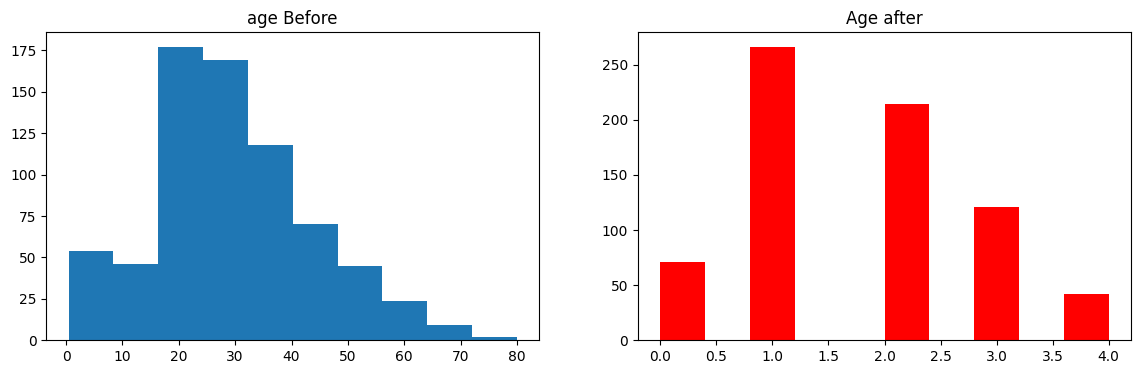

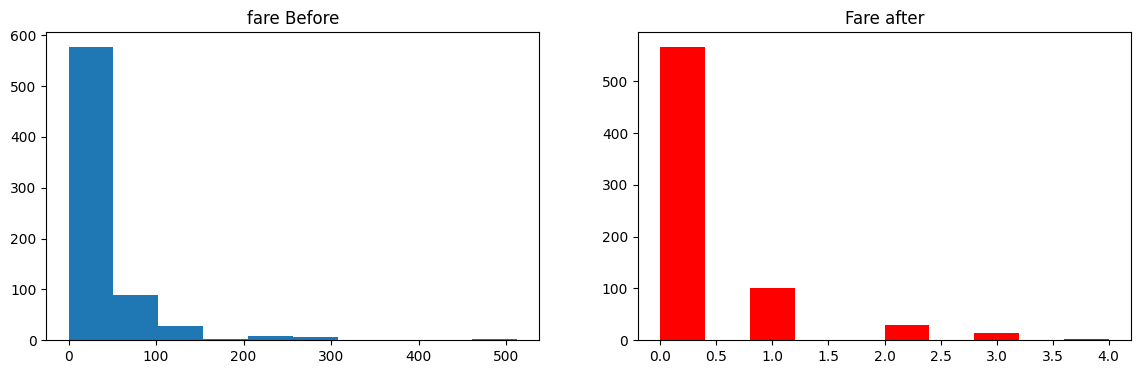

In [ ]:
discretize(5,'kmeans')